# Módulo 10 tarefa 03
Considere a mesma base de dados utilizada na tarefa 1 ```previsao_de_renda.csv```.

1) Construa um gráfico de barras para avaliar a distribuição das variáveis qualitativas no tempo. Você acha que houve alguma alteração importante a ser investigada?

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o dataset
df = pd.read_csv('previsao_de_renda.csv')

# Visualizar as primeiras linhas do dataset
print(df.head())

   Unnamed: 0    data_ref  index sexo  posse_de_veiculo  posse_de_imovel  \
0           0  2015-01-01   8682    F             False             True   
1           1  2015-01-01  12830    M              True             True   
2           2  2015-01-01   2885    M              True             True   
3           3  2015-01-01  16168    F              True            False   
4           4  2015-01-01  12438    M             False            False   

   qtd_filhos   tipo_renda           educacao estado_civil tipo_residencia  \
0           1  Assalariado         Secundário       Casado            Casa   
1           0   Empresário         Secundário       Casado            Casa   
2           2  Assalariado  Superior completo       Casado            Casa   
3           0   Empresário         Secundário       Casado            Casa   
4           0  Assalariado         Secundário       Casado            Casa   

   idade  tempo_emprego  qt_pessoas_residencia    mau    renda  
0     36 

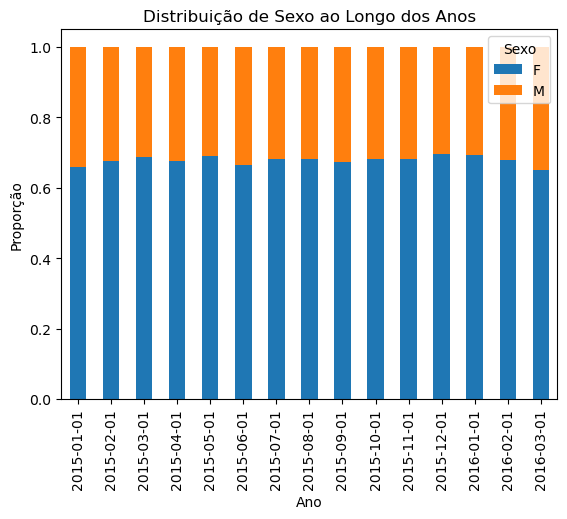

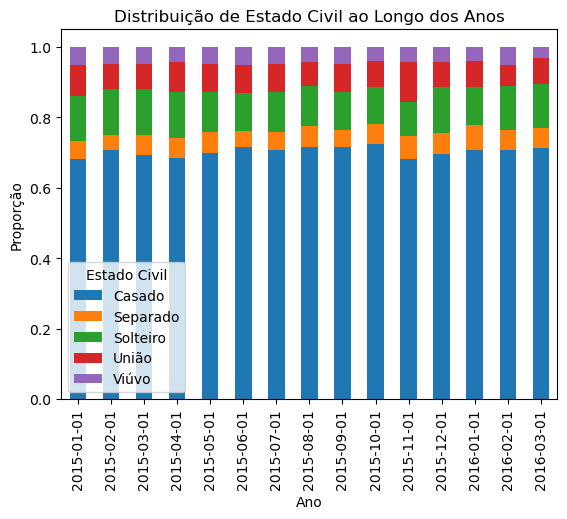

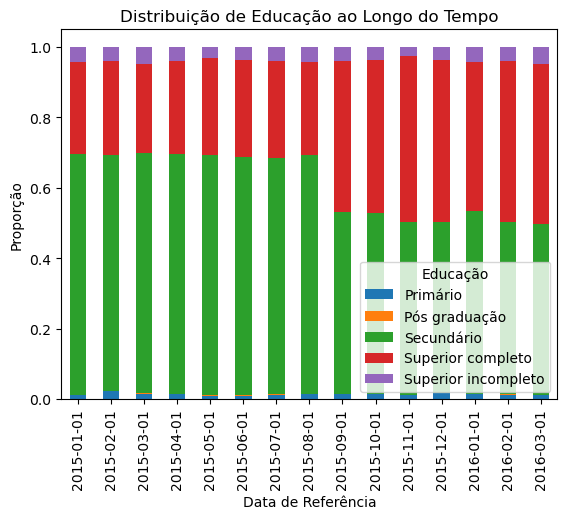

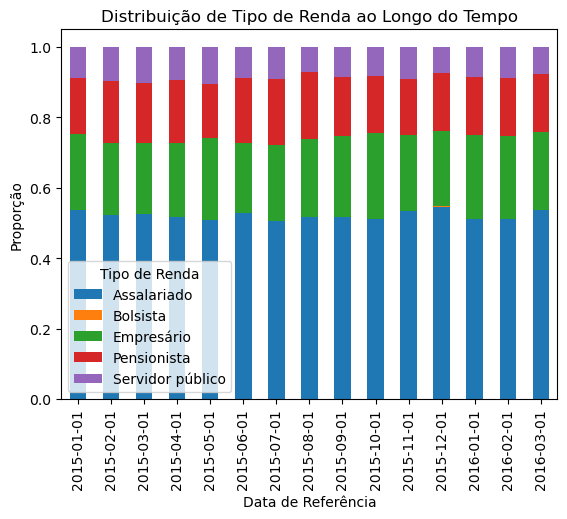

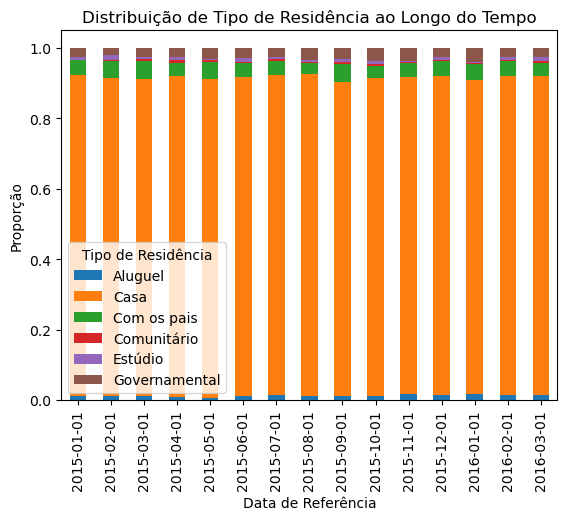

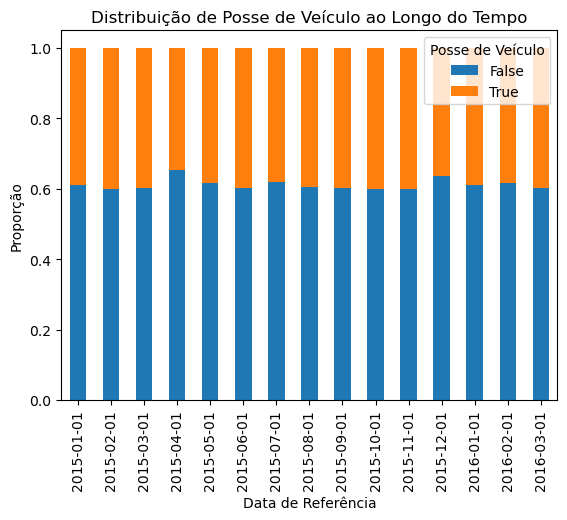

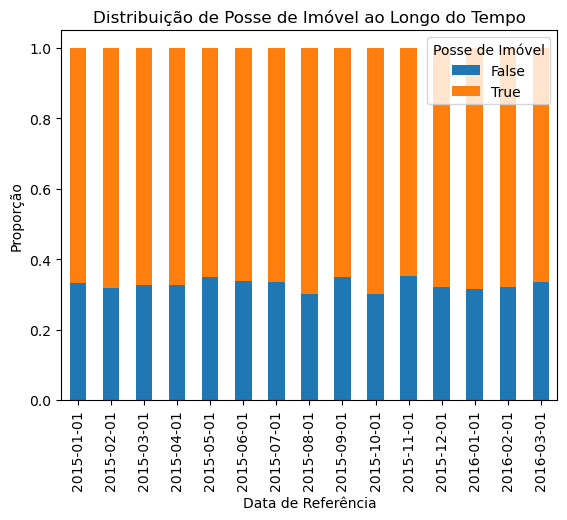

In [5]:
# Gráfico de barras para a variável 'sexo'
df.groupby('data_ref')['sexo'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Distribuição de Sexo ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Proporção')
plt.legend(title='Sexo')
plt.show()

# Gráfico de barras para a variável 'estado_civil'
df.groupby('data_ref')['estado_civil'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Distribuição de Estado Civil ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Proporção')
plt.legend(title='Estado Civil')
plt.show()

# Gráfico de barras para a variável 'educacao'
df.groupby('data_ref')['educacao'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Distribuição de Educação ao Longo do Tempo')
plt.xlabel('Data de Referência')
plt.ylabel('Proporção')
plt.legend(title='Educação')
plt.show()

# Gráfico de barras para a variável 'tipo_renda'
df.groupby('data_ref')['tipo_renda'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Distribuição de Tipo de Renda ao Longo do Tempo')
plt.xlabel('Data de Referência')
plt.ylabel('Proporção')
plt.legend(title='Tipo de Renda')
plt.show()

# Gráfico de barras para a variável 'tipo_residencia'
df.groupby('data_ref')['tipo_residencia'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Distribuição de Tipo de Residência ao Longo do Tempo')
plt.xlabel('Data de Referência')
plt.ylabel('Proporção')
plt.legend(title='Tipo de Residência')
plt.show()

# Gráfico de barras para a variável 'posse_de_veiculo'
df.groupby('data_ref')['posse_de_veiculo'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Distribuição de Posse de Veículo ao Longo do Tempo')
plt.xlabel('Data de Referência')
plt.ylabel('Proporção')
plt.legend(title='Posse de Veículo')
plt.show()

# Gráfico de barras para a variável 'posse_de_imovel'
df.groupby('data_ref')['posse_de_imovel'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Distribuição de Posse de Imóvel ao Longo do Tempo')
plt.xlabel('Data de Referência')
plt.ylabel('Proporção')
plt.legend(title='Posse de Imóvel')
plt.show()


A única variável que apresentou uma mudança de proporção nos grupos foi referente a escolaridade que vemos que ao decorrer do tempo é possível observar uma maior proporção de pessoas com o superior completo ao longo do tempo.

2) Para cada variável qualitativa, construa um gráfico mostrando as médias de cada nível da variável no tempo e avalie a estabilidade. Houve alguma alteração importante? Você acha que se pode utilizar essas variáveis em uma modelagem?

In [20]:
# Extrair as variáveis qualitativas

qualitativas = [col for col in df.columns if df[col].dtype == 'object' or df[col].dtype == 'bool']

# Mostrar informações sobre as variáveis qualitativas

print(df[qualitativas].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   data_ref          15000 non-null  object
 1   sexo              15000 non-null  object
 2   posse_de_veiculo  15000 non-null  bool  
 3   posse_de_imovel   15000 non-null  bool  
 4   tipo_renda        15000 non-null  object
 5   educacao          15000 non-null  object
 6   estado_civil      15000 non-null  object
 7   tipo_residencia   15000 non-null  object
 8   mau               15000 non-null  bool  
dtypes: bool(3), object(6)
memory usage: 747.2+ KB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   sexo              15000 non-null  object
 1   posse_de_veiculo  15000 non-null  bool  
 2   posse_de_imovel   15000 non-null  bool  
 3   tipo_renda        15000 non-null  object
 4   educacao          15000 non-null  object
 5   estado_civil      15000 non-null  object
 6   tipo_residencia   15000 non-null  object
 7   mau               15000 non-null  bool  
dtypes: bool(3), object(5)
memory usage: 630.0+ KB
None


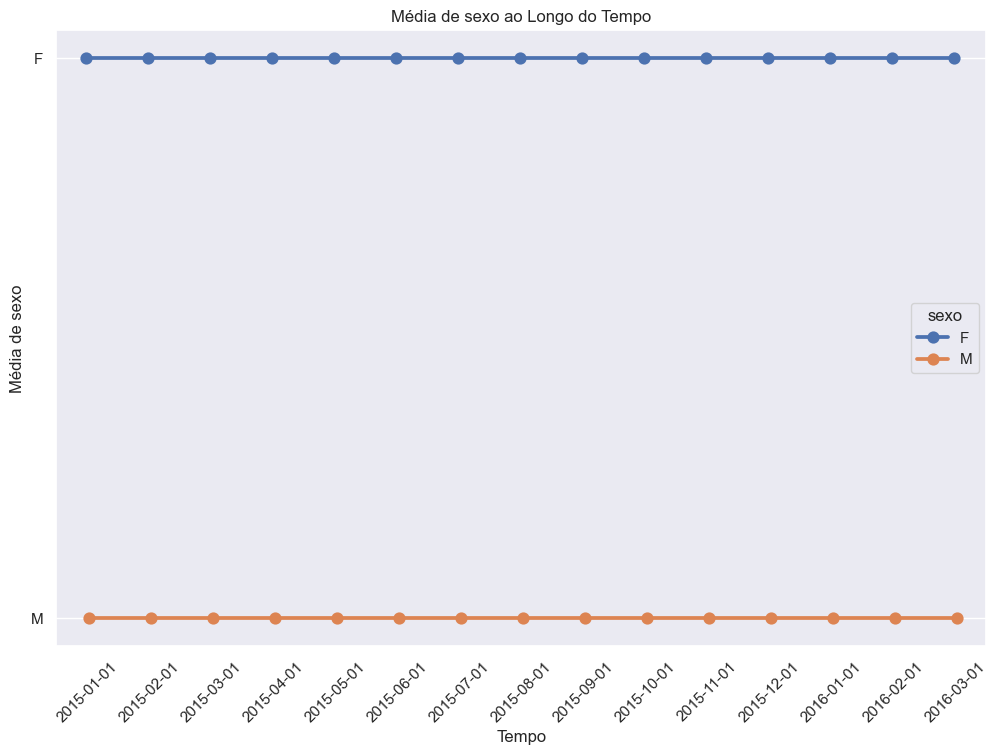

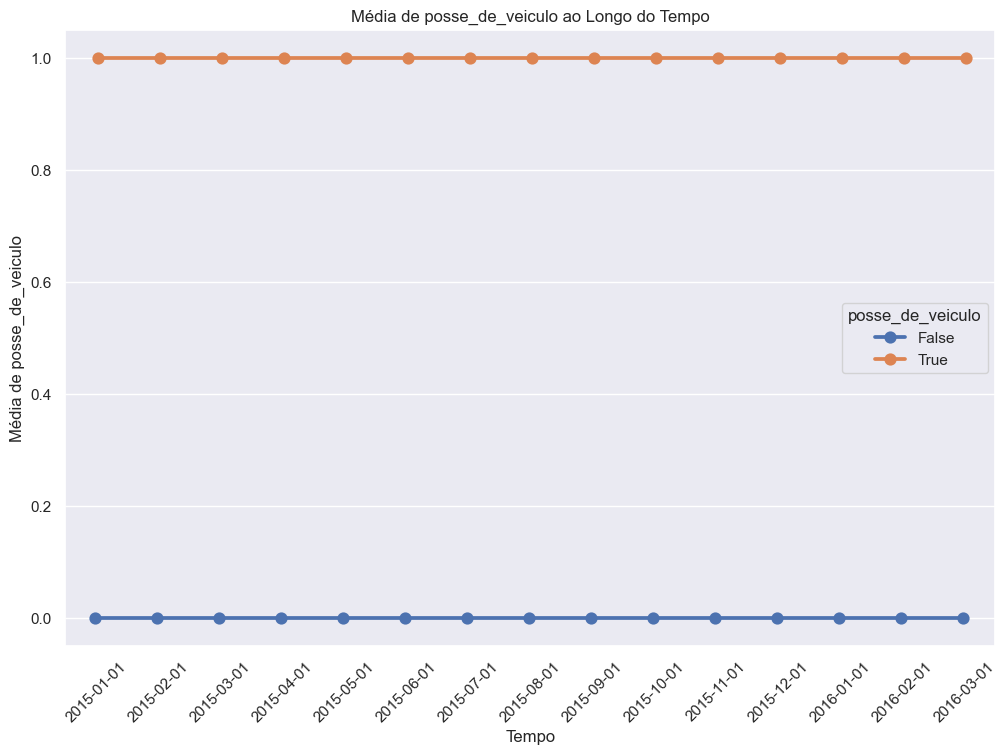

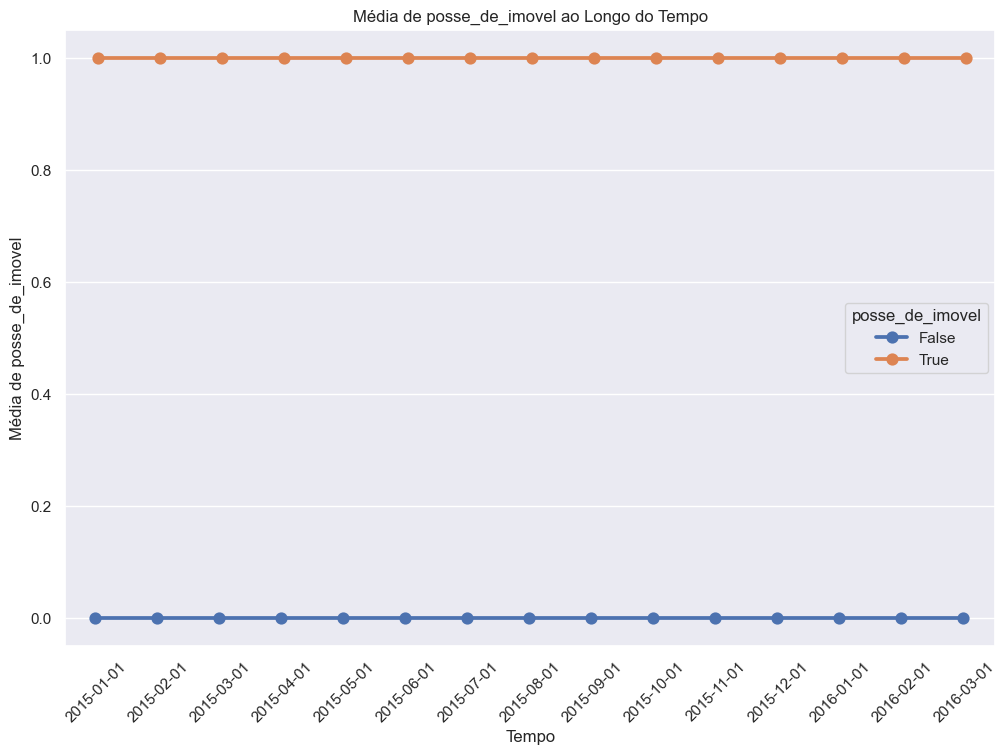

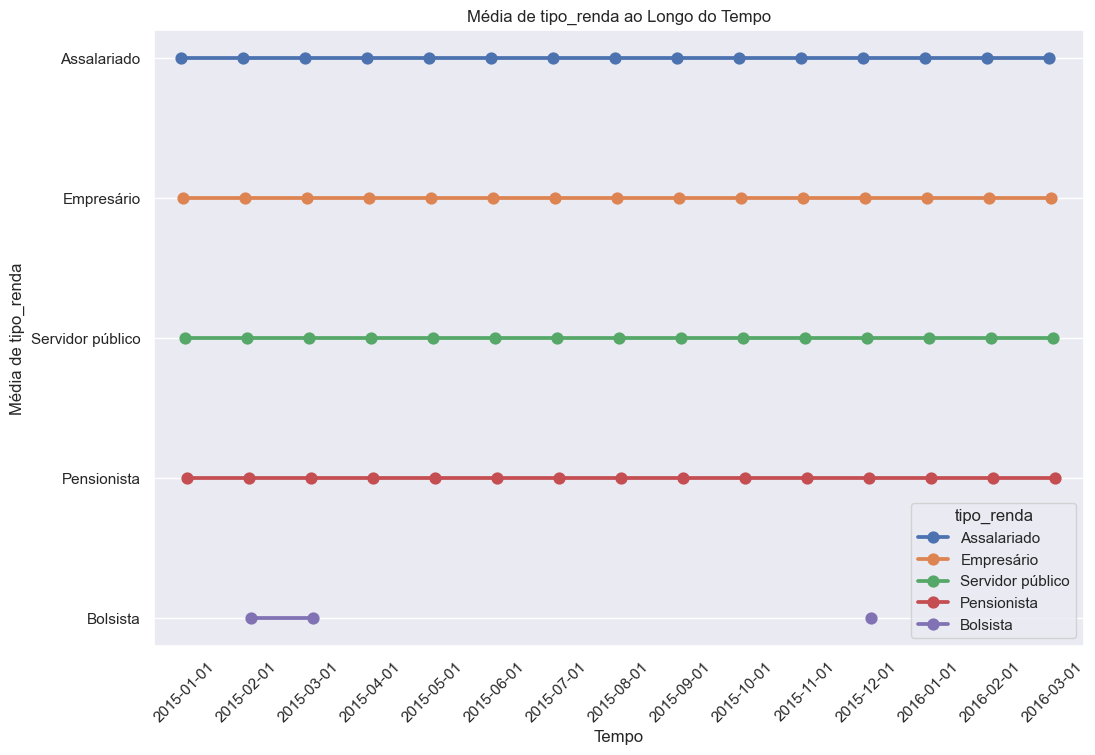

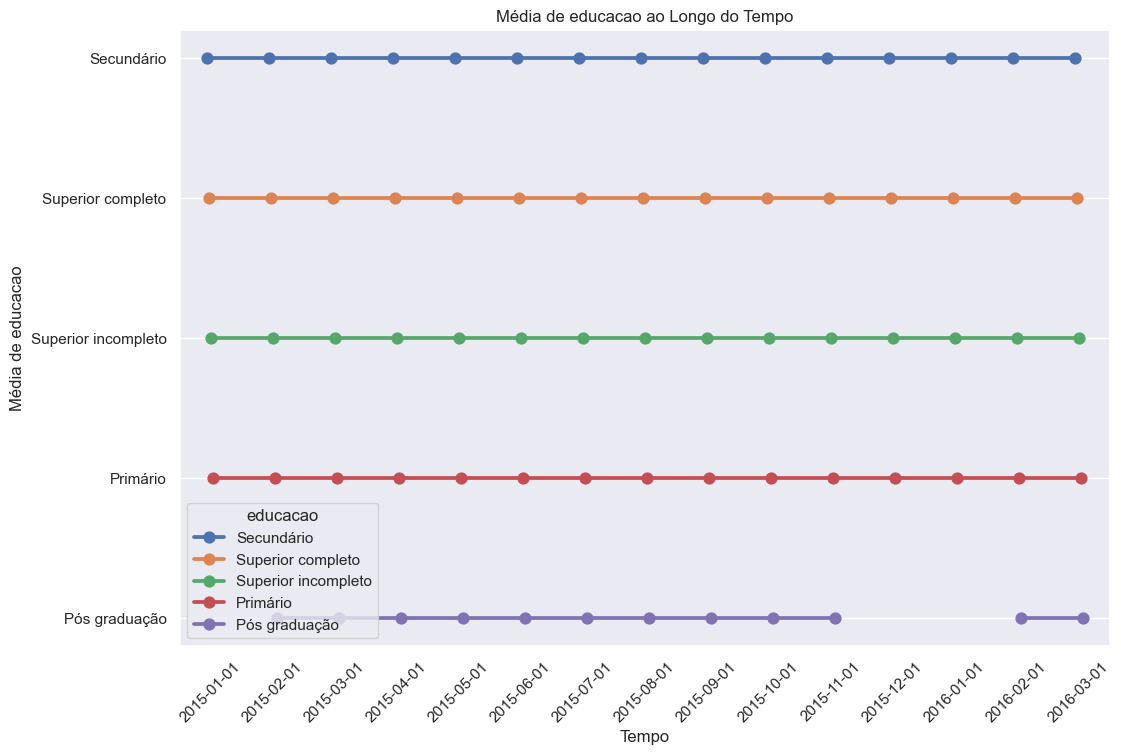

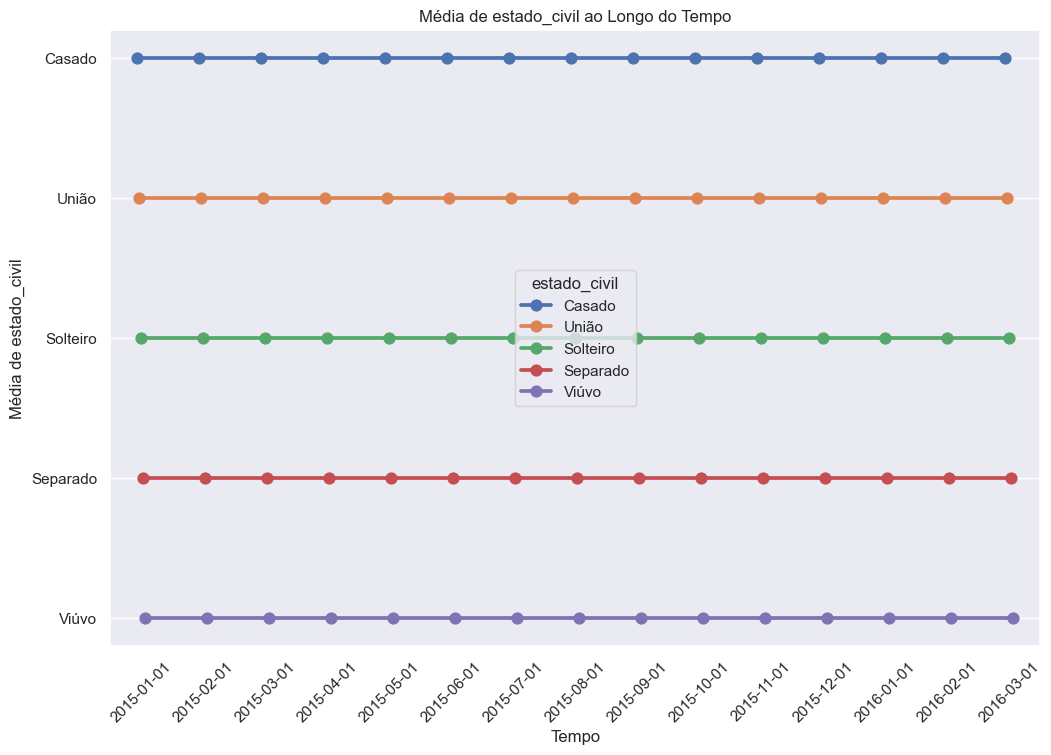

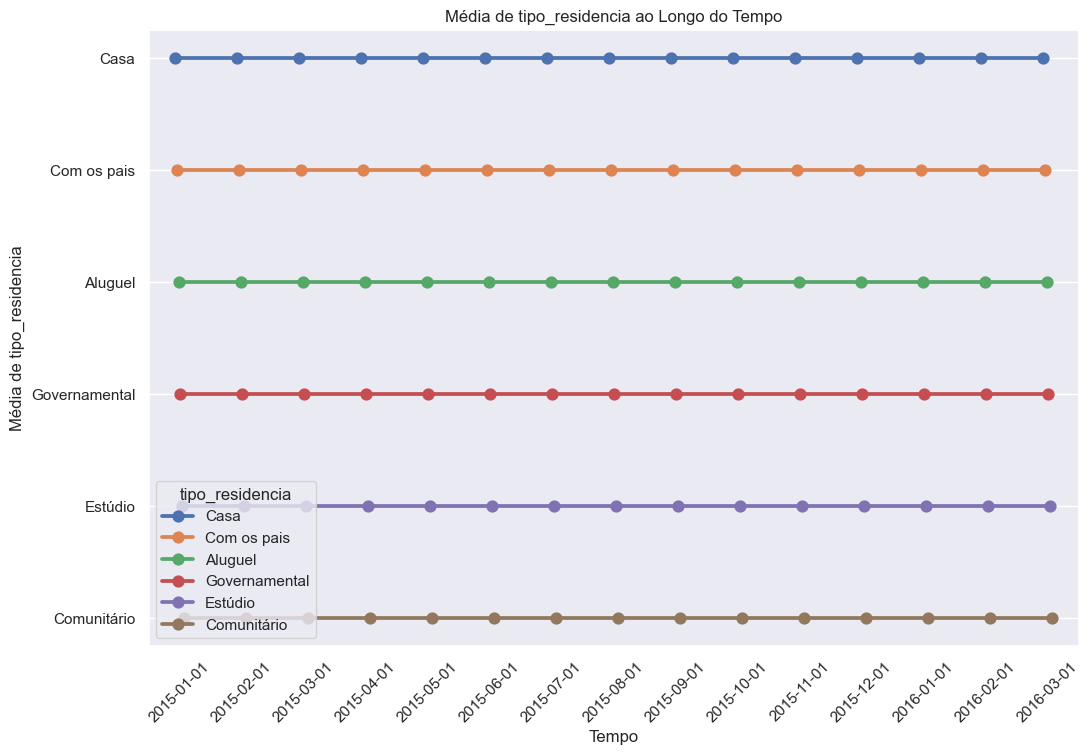

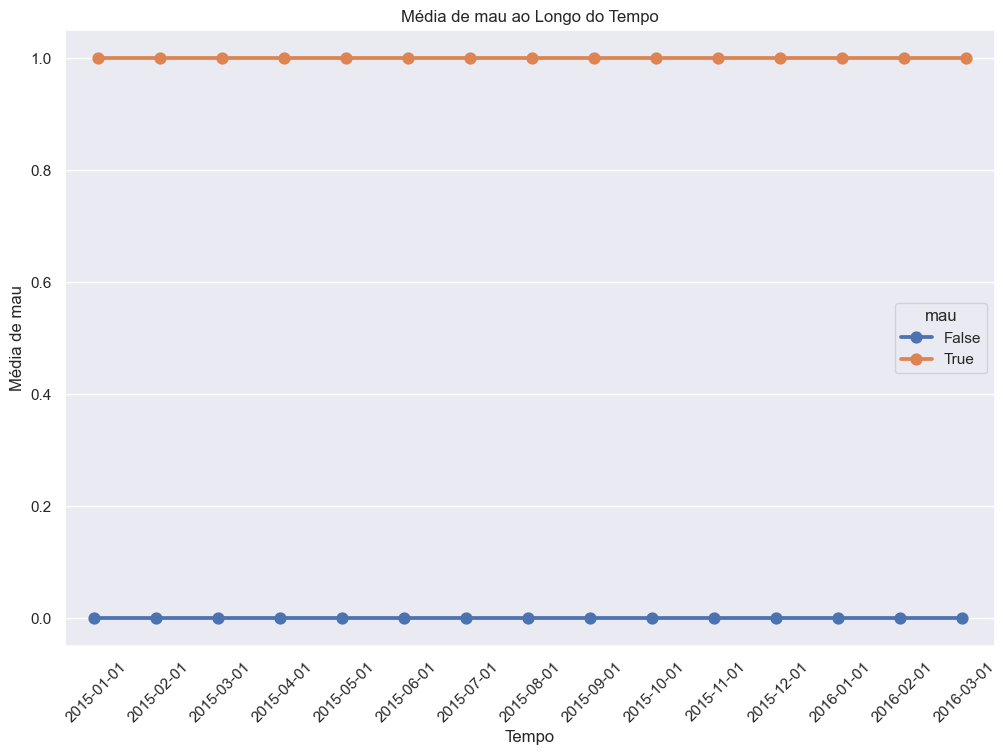

In [22]:
def plot_categorical_variables_exclude_data_ref(df):
    # Extrair as variáveis categóricas, excluindo 'data_ref'
    qualitativas = [col for col in df.columns if (df[col].dtype == 'object' or df[col].dtype == 'bool') and col != 'data_ref']

    # Mostrar informações sobre as variáveis qualitativas
    print(df[qualitativas].info())

    # Plote os gráficos para cada variável qualitativa
    for var in qualitativas:
        plt.figure(figsize=(12, 8))
        sns.pointplot(data=df, x='data_ref', y=var, hue=var, dodge=True)
        plt.title(f'Média de {var} ao Longo do Tempo')
        plt.xlabel('Tempo')
        plt.ylabel(f'Média de {var}')
        plt.legend(title=var)
        plt.xticks(rotation=45)
        plt.show()

plot_categorical_variables_exclude_data_ref(df)

A média em relação ao tipo de renda, foi observado que bolsistas foi uma categoria que houve alteração na quantidade dessa categoria na variável. Também foi observado isso em relação ao nível de escolaridade, aqueles com pós graduação tiveram uma alteração entre o mês 12 de 2015 e 01 de 2016.